# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('..//content/drive/MyDrive/Analytics_HW/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [5]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

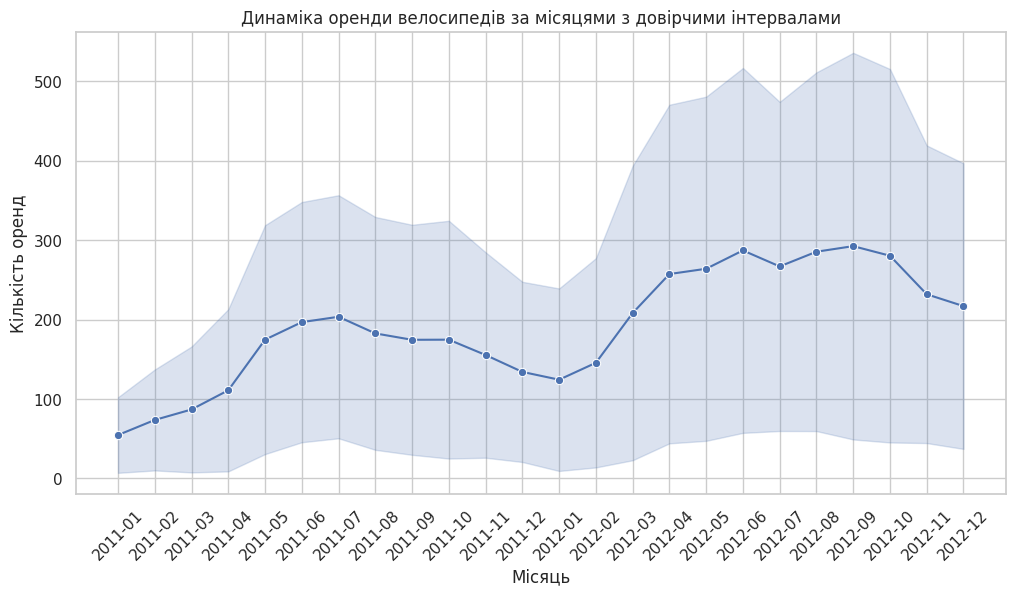

In [6]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x='month_year',
    y='count',
    marker='o',
    errorbar='sd'
)

plt.title('Динаміка оренди велосипедів за місяцями з довірчими інтервалами')

plt.xlabel('Місяць')
plt.ylabel('Кількість оренд')

plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Найбільша невизначеність спостерігається у місяцях із найвищою активністю оренди, оскільки в ці періоди варіативність даних є більшою. Це видно по ширших довірчих інтервалах на графіку. Найбільша невизначеність спостерігається у місяцях із найвищою активністю оренди, оскільки в ці періоди варіативність даних є більшою. Це видно по ширших довірчих інтервалах на графіку.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

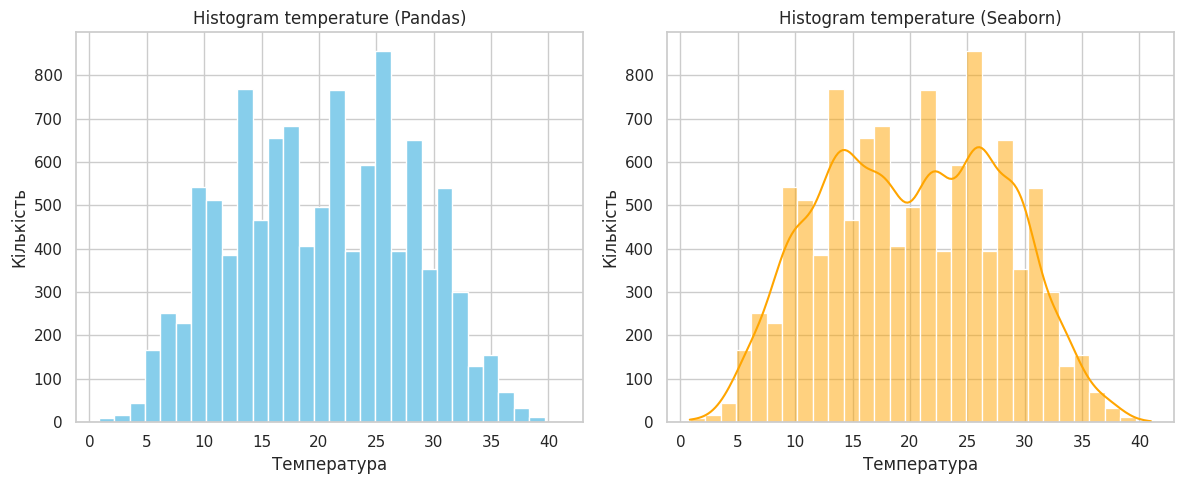

In [7]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

# 1️. Pandas histogram
df['temp'].plot(
    kind='hist',
    bins=30,
    ax=ax[0],
    color='skyblue'
)

ax[0].set_title('Histogram temperature (Pandas)')
ax[0].set_xlabel('Температура')
ax[0].set_ylabel('Кількість')


# 2️. Seaborn histogram
sns.histplot(
    data=df,
    x='temp',
    bins=30,
    kde=True,
    ax=ax[1],
    color='orange'
)

ax[1].set_title('Histogram temperature (Seaborn)')
ax[1].set_xlabel('Температура')
ax[1].set_ylabel('Кількість')


plt.tight_layout()
plt.show()

1. Гістограма Seaborn має більш сучасний вигляд та кращий стандартний стиль. Pandas гістограма є простішою та базується на Matplotlib без додаткових статистичних елементів.
2. Додаткова лінія на графіку Seaborn - це KDE (Kernel Density Estimation). Вона показує згладжений розподіл даних і допомагає краще побачити форму розподілу температур.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

In [8]:
weather_labels = {
    1:'Clear',
    2:'Mist',
    3:'Light rain',
    4:'Heavy rain'
}

df['weather_name'] = df['weather'].map(weather_labels)

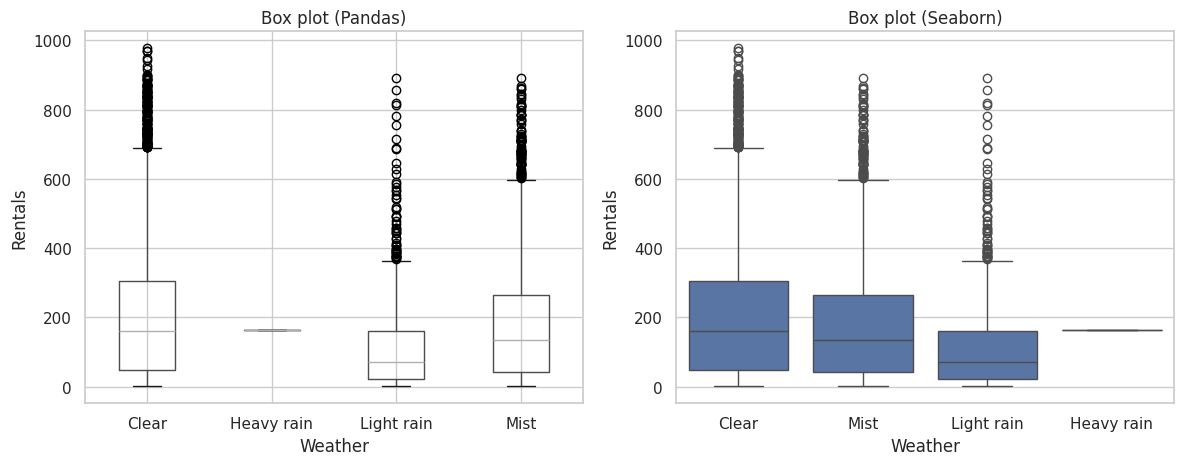

In [9]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

# 1️. Pandas boxplot
df.boxplot(
    column='count',
    by='weather_name',
    ax=ax[0]
)

ax[0].set_title('Box plot (Pandas)')
ax[0].set_xlabel('Weather')
ax[0].set_ylabel('Rentals')


# 2️. Seaborn boxplot
sns.boxplot(
    data=df,
    x='weather_name',
    y='count',
    ax=ax[1]
)

ax[1].set_title('Box plot (Seaborn)')
ax[1].set_xlabel('Weather')
ax[1].set_ylabel('Rentals')


plt.suptitle('')
plt.tight_layout()
plt.show()

Box plot Seaborn виглядає більш сучасно та має кращий стандартний стиль. Pandas box plot є простішим та базується на стандартних налаштуваннях Matplotlib. Seaborn забезпечує кращу візуальну читабельність та більш акуратне оформлення графіка (бо ж спеціалізується на статистичних візуалізаціях, тому його графіки виглядають більш інформативно).

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


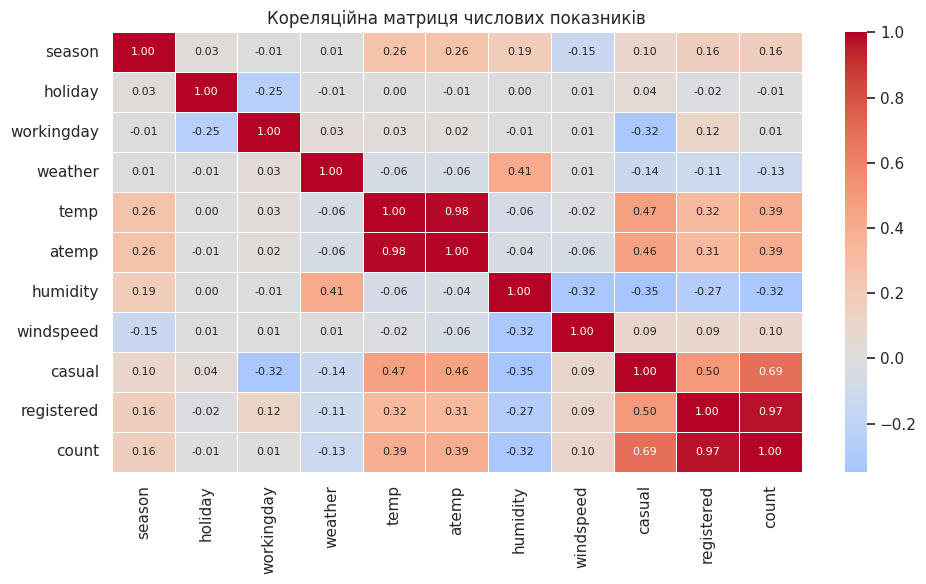

In [12]:
corr = df[['season','holiday','workingday','weather',
           'temp','atemp','humidity','windspeed',
           'casual','registered','count']].corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size':8}
)

plt.title('Кореляційна матриця числових показників')
plt.tight_layout()
plt.show()

1. Найсильнішу позитивну кореляцію з кількістю оренд мають температура (temp=0.98), відчутна температура (atemp=0.98) та кількість зареєстрованих користувачів (registered-0.97).
2. Кореляція між temp та atemp дуже висока (близька до 1), оскільки відчутна температура розраховується на основі фактичної температури.
3. Негативну кореляцію з кількістю оренд мають вологість (humidity) та погодні умови (weather), що пояснюється тим, що несприятлива погода зменшує попит на оренду велосипедів.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


In [15]:
def india_season(month):
    if month in [12,1,2]:
        return 1
    elif month in [3,4,5]:
        return 2
    elif month in [6,7,8,9]:
        return 3
    else:
        return 4

df['weather_season_india'] = df['month'].apply(india_season)

In [17]:
season_india = {
    1:'Winter',
    2:'Summer',
    3:'Monsoon',
    4:'Post-Monsoon'
}

df['season_india'] = df['weather_season_india'].map(season_india)

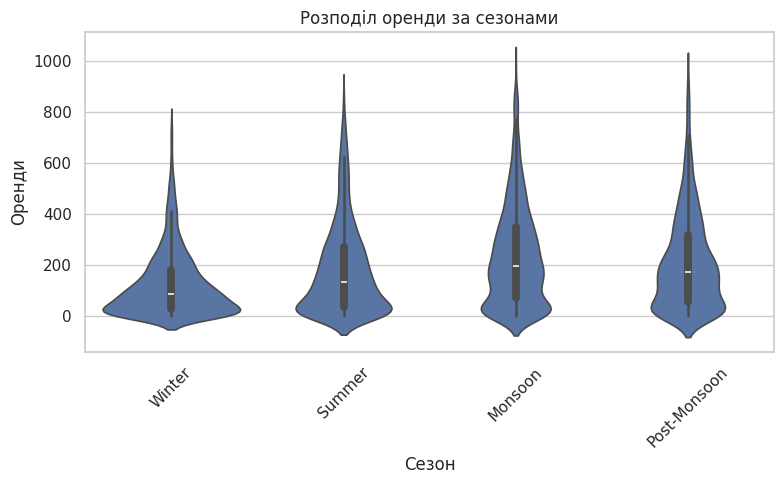

In [19]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x='season_india',
    y='count',
    order=['Winter','Summer','Monsoon','Post-Monsoon']
)

plt.xticks(rotation=45)
plt.title('Розподіл оренди за сезонами')
plt.xlabel('Сезон')
plt.ylabel('Оренди')

plt.tight_layout()

plt.show()

1. Товщина violin plot показує щільність даних. Чим ширший графік у певному місці, тим більше значень зосереджено в цьому діапазоні.
2. Найбільша варіабельність спостерігається у теплі квартали (Monsoon), де попит на оренду є найвищим.
3. Violin plot показує не лише медіану та квартилі, а й форму розподілу даних, що дозволяє краще зрозуміти структуру даних.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

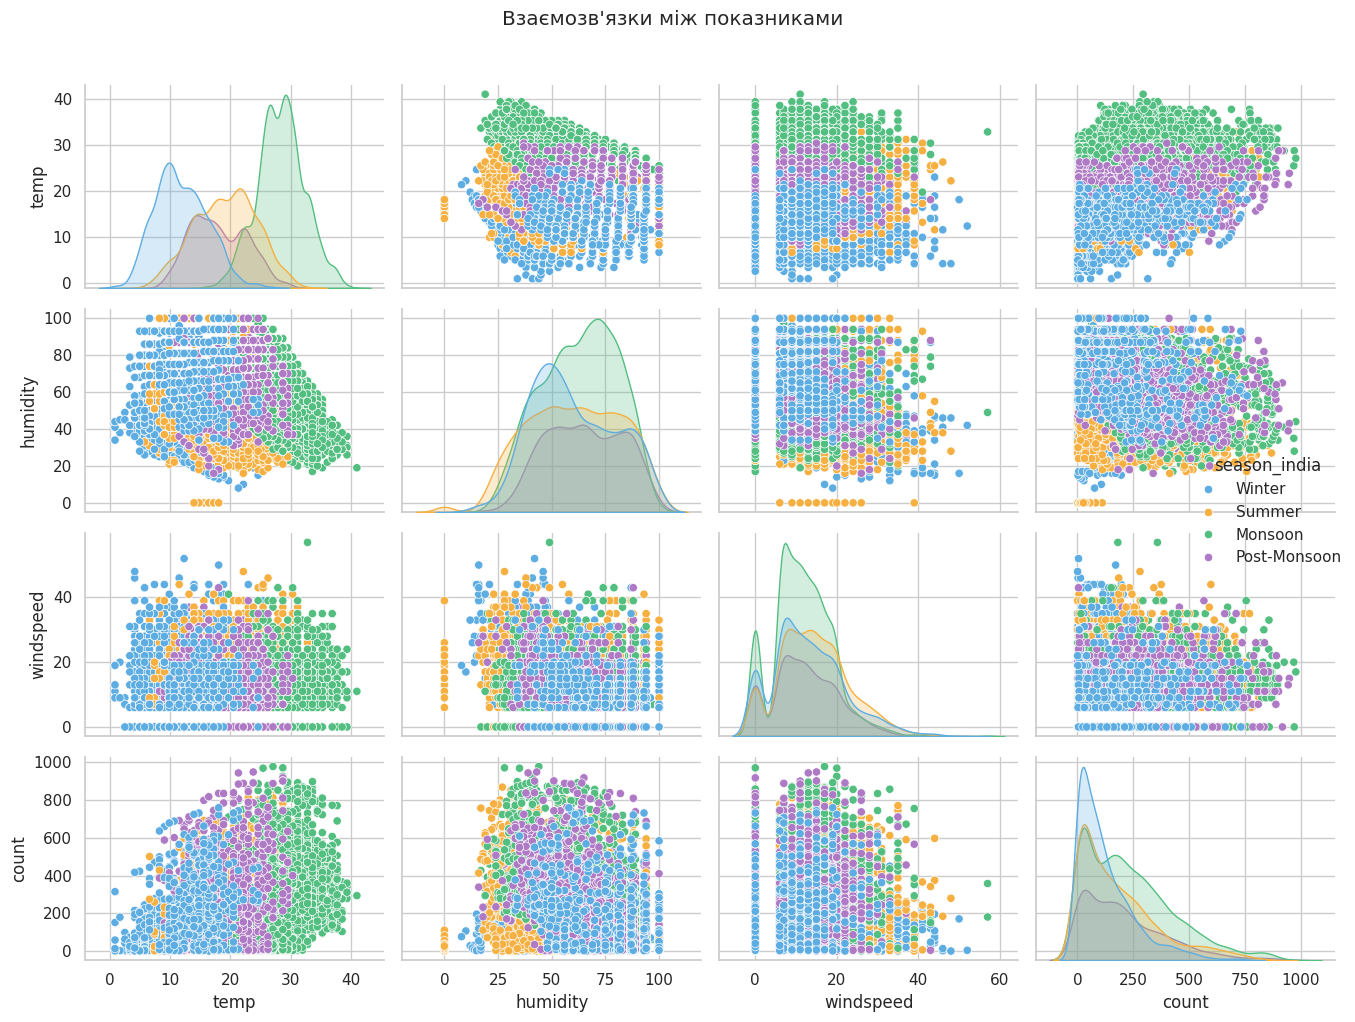

In [28]:
sns.pairplot(
    df[['temp','humidity','windspeed','count','season_india']],
            hue='season_india',
    palette = {
    'Winter':'#5DADE2',
    'Summer':'#F5B041',
    'Monsoon':'#52BE80',
    'Post-Monsoon':'#AF7AC5'
},
    height=2.5,
    aspect=1.2,
    diag_kind='kde'
)
plt.suptitle("Взаємозв'язки між показниками", y=1.02)
plt.tight_layout()
plt.show()

1. Найсильніший лінійний зв'язок спостерігається між температурою та кількістю оренд.
2. Найбільше між кварталами відрізняється кількість оренд та температура.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

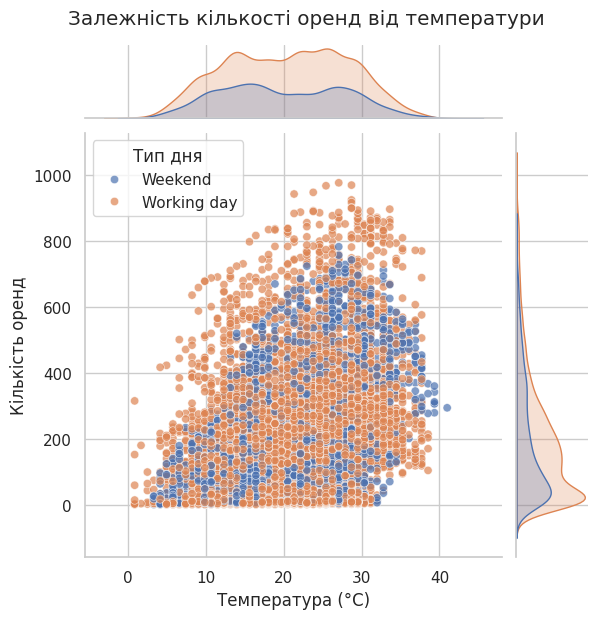

In [30]:
df['day_type'] = df['workingday'].replace({
    0:'Weekend',
    1:'Working day'
})

jp = sns.jointplot(
    data=df,
    x='temp',
    y='count',
    hue='day_type',
    height=6,
    alpha=0.7
)

jp.fig.suptitle('Залежність кількості оренд від температури', y=1.03)
jp.set_axis_labels('Температура (°C)', 'Кількість оренд')
jp.ax_joint.legend(title='Тип дня', loc='upper left')
plt.show()

1. Графіки по краях показують розподіл кожної змінної окремо (кількість оренд до температури), цей розподіл не є рівномірним.
2. Між робочими та неробочими днями є різниця, оскільки поведінка користувачів змінюється залежно від типу дня.Саме в будні(робочі) дні більше оренд велосипедів, тоді як у вихідні - менше.